# DiffTMM — Forward Simulation

This notebook demonstrates forward simulation using `IsotropicFilmSolver` (2×2 transfer matrix method).

**Film stack:** Glass | Ta₂O₅ | SiO₂ | Ta₂O₅ | Glass

We compute Fresnel coefficients (ts, tp, rs, rp) as a function of angle and wavelength, then visualize transmittance, reflectance, and energy conservation.

## 0 · Imports & device

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

from film_solver_isotropic import IsotropicFilmSolver

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

Device: cuda


## 1 · Define the film stack

In [2]:
# Glass(1.5) | Ta2O5(2.10, 80nm) | SiO2(1.46, 120nm) | Ta2O5(2.10, 80nm) | Glass(1.5)
n_in           = 1.50
n_out          = 1.50
n_layers_list  = [2.10, 1.46, 2.10]   # interior layer indices
d_target       = [0.080, 0.120, 0.080] # thicknesses in µm

wvlns = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]  # µm
wvlns_nm = [int(w * 1000) for w in wvlns]

solver = IsotropicFilmSolver(
    n_in=n_in,
    n_out=n_out,
    n_layers_list=n_layers_list,
    d_layers=d_target,
    n_mirrors=1,
    device=device,
)

print("Film stack:")
print(f"  Glass (n={n_in}) → Ta₂O₅ (n=2.10, d={d_target[0]*1e3:.0f} nm) → "
      f"SiO₂ (n=1.46, d={d_target[1]*1e3:.0f} nm) → "
      f"Ta₂O₅ (n=2.10, d={d_target[2]*1e3:.0f} nm) → Glass (n={n_out})")
print(f"Thicknesses from solver: {solver.get_film_thickness().tolist()} µm")

Film stack:
  Glass (n=1.5) → Ta₂O₅ (n=2.10, d=80 nm) → SiO₂ (n=1.46, d=120 nm) → Ta₂O₅ (n=2.10, d=80 nm) → Glass (n=1.5)
Thicknesses from solver: [[0.07999999821186066, 0.11999999731779099, 0.07999999821186066]] µm


### Film stack diagram

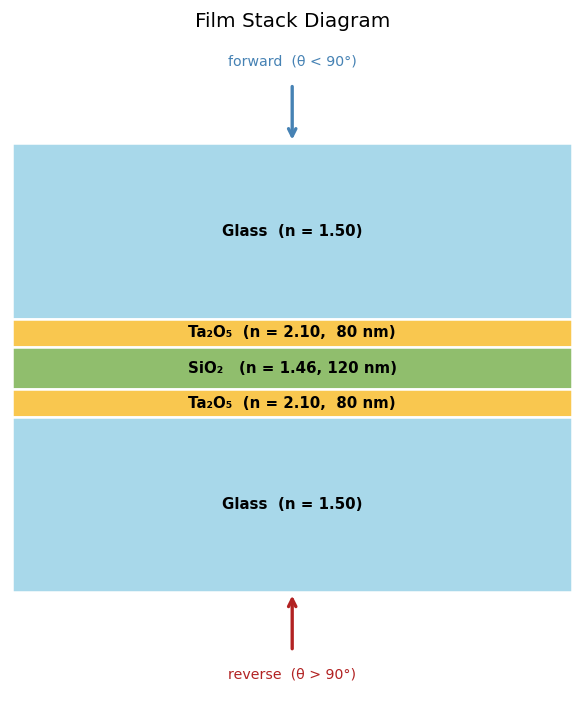

In [3]:
fig, ax = plt.subplots(figsize=(5, 6))

# Layers from top (incident) to bottom (exit): (label, thickness_nm, color)
layers = [
    ("Glass  (n = 1.50)",          500, "#a8d8ea"),
    ("Ta₂O₅  (n = 2.10,  80 nm)",   80, "#f9c74f"),
    ("SiO₂   (n = 1.46, 120 nm)",  120, "#90be6d"),
    ("Ta₂O₅  (n = 2.10,  80 nm)",   80, "#f9c74f"),
    ("Glass  (n = 1.50)",          500, "#a8d8ea"),
]

# Normalize display heights so total fits plot height = 4.5
scale = 4.5 / sum(l[1] for l in layers)

y = 4.5  # start from top
for label, th_nm, color in layers:
    h = th_nm * scale
    ax.add_patch(plt.Rectangle((0, y - h), 1, h, color=color, ec="white", lw=1.5))
    ax.text(0.5, y - h / 2, label, ha="center", va="center", fontsize=9, fontweight="bold")
    y -= h

# Forward direction: light from above (θ < 90°)
ax.annotate("", xy=(0.5, 4.5), xytext=(0.5, 5.1),
            arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
ax.text(0.5, 5.25, "forward  (θ < 90°)", ha="center", va="bottom", fontsize=8.5, color="steelblue")

# Reverse direction: light from below (θ > 90°)
ax.annotate("", xy=(0.5, 0.0), xytext=(0.5, -0.6),
            arrowprops=dict(arrowstyle="->", color="firebrick", lw=2))
ax.text(0.5, -0.75, "reverse  (θ > 90°)", ha="center", va="top", fontsize=8.5, color="firebrick")

ax.set_xlim(0, 1)
ax.set_ylim(-1.0, 5.5)
ax.axis("off")
ax.set_title("Film Stack Diagram", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## 2 · Angle sweep at multiple wavelengths

In [4]:
N_angles = 360
# Full range 0 → 180°: forward (0–90°) and reverse (90–180°) propagation
angles = torch.linspace(0.0, torch.pi, N_angles, device=device)
angles_deg = angles.cpu().numpy() * 180 / np.pi

ts, tp, rs, rp = solver.simulate(theta=angles, wvln=wvlns)
# Shape: (n_mirrors=1, n_wvlns=7, n_angles=360)

# Power coefficients
Ts = (ts[0].abs() ** 2).cpu().numpy()  # (n_wvlns, n_angles)
Tp = (tp[0].abs() ** 2).cpu().numpy()
Rs = (rs[0].abs() ** 2).cpu().numpy()
Rp = (rp[0].abs() ** 2).cpu().numpy()

print(f"Output shape per coefficient: {ts.shape}  (n_mirrors, n_wvlns, n_angles)")

Output shape per coefficient: torch.Size([1, 7, 360])  (n_mirrors, n_wvlns, n_angles)


### 2a · Transmittance vs. angle

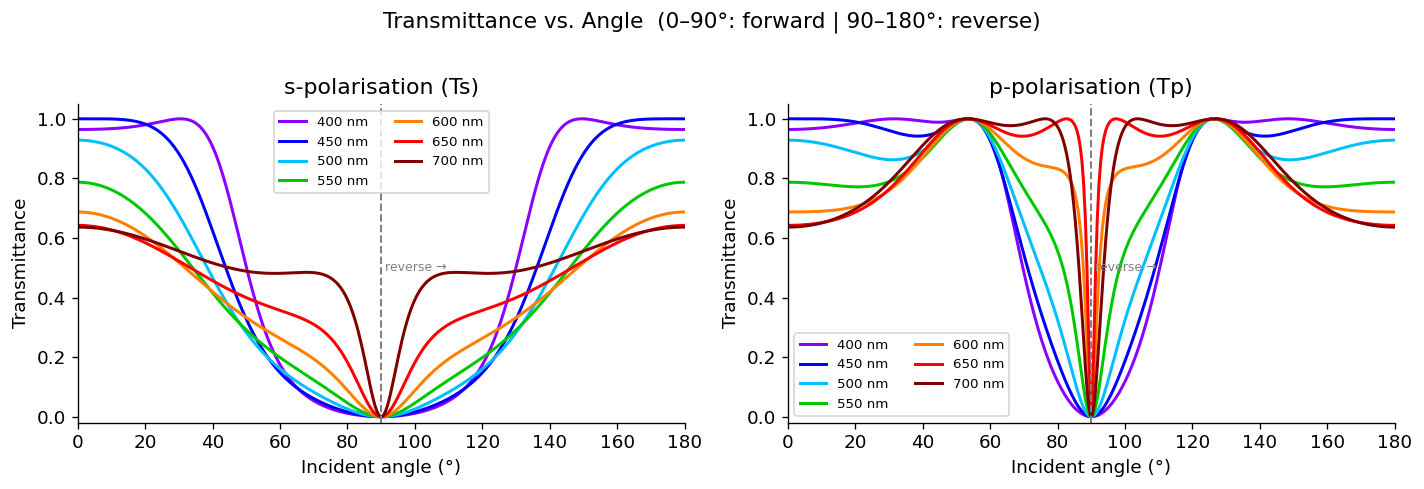

In [5]:
# Colour-code by wavelength (approximate visible colours)
vis_colors = ["#8b00ff", "#0000ff", "#00c0ff", "#00c800", "#ff8000", "#ff0000", "#800000"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for i, (wv_nm, c) in enumerate(zip(wvlns_nm, vis_colors)):
    axes[0].plot(angles_deg, Ts[i], color=c, label=f"{wv_nm} nm", lw=1.8)
    axes[1].plot(angles_deg, Tp[i], color=c, label=f"{wv_nm} nm", lw=1.8)

for ax, pol in zip(axes, ["s-polarisation (Ts)", "p-polarisation (Tp)"]):
    ax.axvline(90, color="gray", lw=1.2, ls="--")
    ax.text(91, 0.5, "reverse →", fontsize=7.5, color="gray", va="center")
    ax.set_xlabel("Incident angle (°)")
    ax.set_ylabel("Transmittance")
    ax.set_title(pol)
    ax.set_xlim(0, 180)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle("Transmittance vs. Angle  (0–90°: forward | 90–180°: reverse)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2b · Reflectance vs. angle

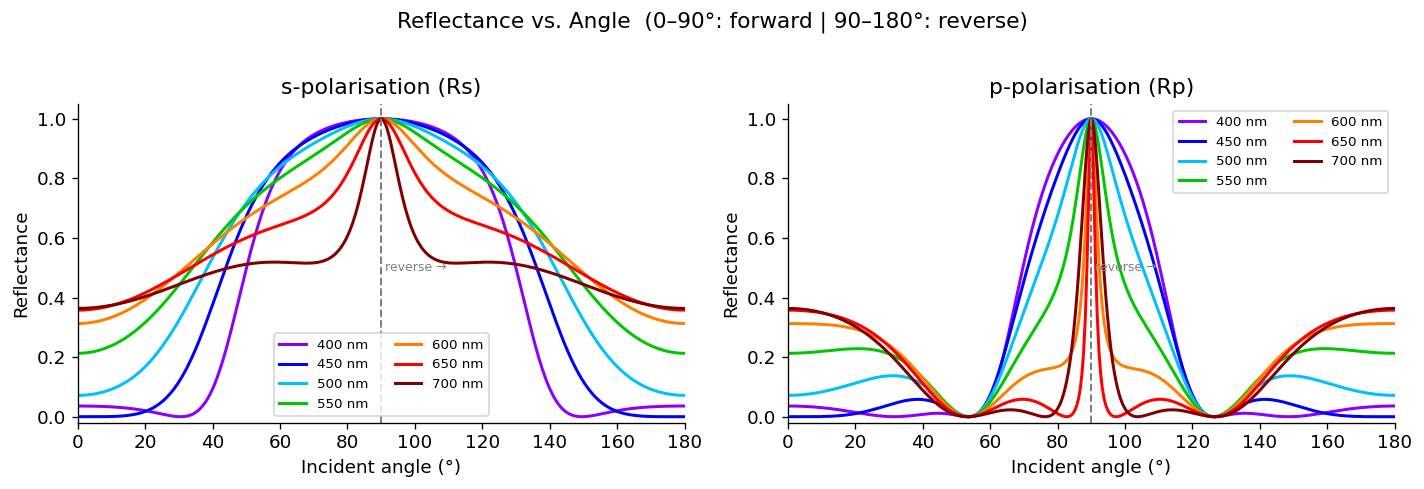

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for i, (wv_nm, c) in enumerate(zip(wvlns_nm, vis_colors)):
    axes[0].plot(angles_deg, Rs[i], color=c, label=f"{wv_nm} nm", lw=1.8)
    axes[1].plot(angles_deg, Rp[i], color=c, label=f"{wv_nm} nm", lw=1.8)

for ax, pol in zip(axes, ["s-polarisation (Rs)", "p-polarisation (Rp)"]):
    ax.axvline(90, color="gray", lw=1.2, ls="--")
    ax.text(91, 0.5, "reverse →", fontsize=7.5, color="gray", va="center")
    ax.set_xlabel("Incident angle (°)")
    ax.set_ylabel("Reflectance")
    ax.set_title(pol)
    ax.set_xlim(0, 180)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle("Reflectance vs. Angle  (0–90°: forward | 90–180°: reverse)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2c · Energy conservation (T + R ≈ 1)

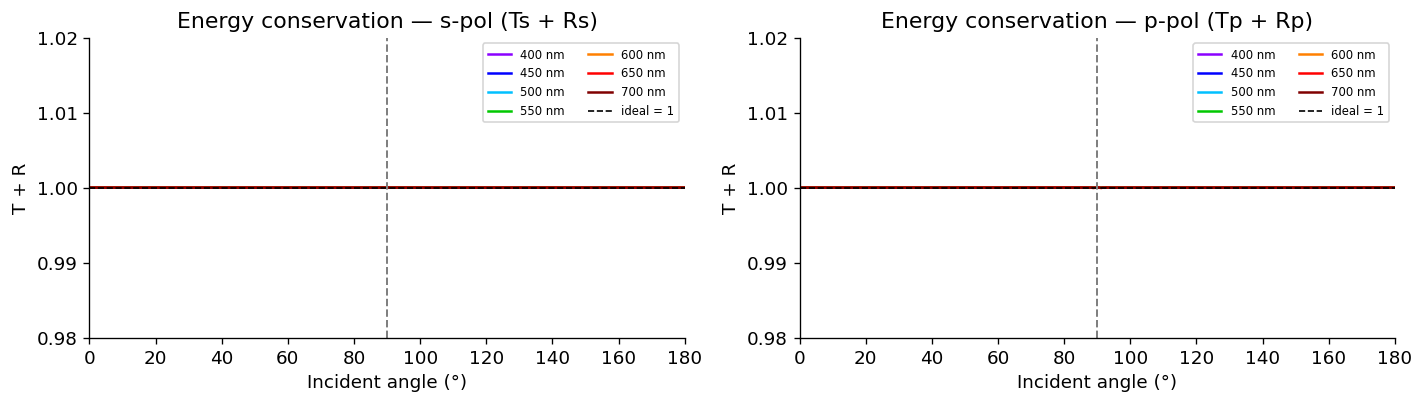

Max |T+R−1|  s-pol: 2.38e-06   p-pol: 4.83e-05


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

for i, (wv_nm, c) in enumerate(zip(wvlns_nm, vis_colors)):
    axes[0].plot(angles_deg, Ts[i] + Rs[i], color=c, label=f"{wv_nm} nm", lw=1.5)
    axes[1].plot(angles_deg, Tp[i] + Rp[i], color=c, label=f"{wv_nm} nm", lw=1.5)

for ax, pol in zip(axes, ["s-pol (Ts + Rs)", "p-pol (Tp + Rp)"]):
    ax.axhline(1.0, color="k", lw=1, ls="--", label="ideal = 1")
    ax.axvline(90, color="gray", lw=1.2, ls="--")
    ax.set_xlabel("Incident angle (°)")
    ax.set_ylabel("T + R")
    ax.set_title(f"Energy conservation — {pol}")
    ax.set_xlim(0, 180)
    ax.set_ylim(0.98, 1.02)
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# Numeric check
max_err_s = np.abs(Ts + Rs - 1).max()
max_err_p = np.abs(Tp + Rp - 1).max()
print(f"Max |T+R−1|  s-pol: {max_err_s:.2e}   p-pol: {max_err_p:.2e}")

## 3 · Wavelength sweep at fixed angles

In [8]:
N_wv = 300
wvlns_sweep = torch.linspace(0.38, 0.72, N_wv).tolist()  # µm
wvlns_sweep_nm = np.linspace(380, 720, N_wv)

fixed_angles_deg = [0, 20, 40, 60]
fixed_angles_rad = torch.tensor([a * np.pi / 180 for a in fixed_angles_deg], device=device)

ts_w, tp_w, rs_w, rp_w = solver.simulate(theta=fixed_angles_rad, wvln=wvlns_sweep)
# Shape: (1, N_wv, 4)

Ts_w = (ts_w[0].abs() ** 2).cpu().numpy()  # (N_wv, 4)
Tp_w = (tp_w[0].abs() ** 2).cpu().numpy()
Rs_w = (rs_w[0].abs() ** 2).cpu().numpy()
Rp_w = (rp_w[0].abs() ** 2).cpu().numpy()

print(f"Wavelength sweep shape: {ts_w.shape}  (n_mirrors, n_wvlns, n_angles)")

Wavelength sweep shape: torch.Size([1, 300, 4])  (n_mirrors, n_wvlns, n_angles)


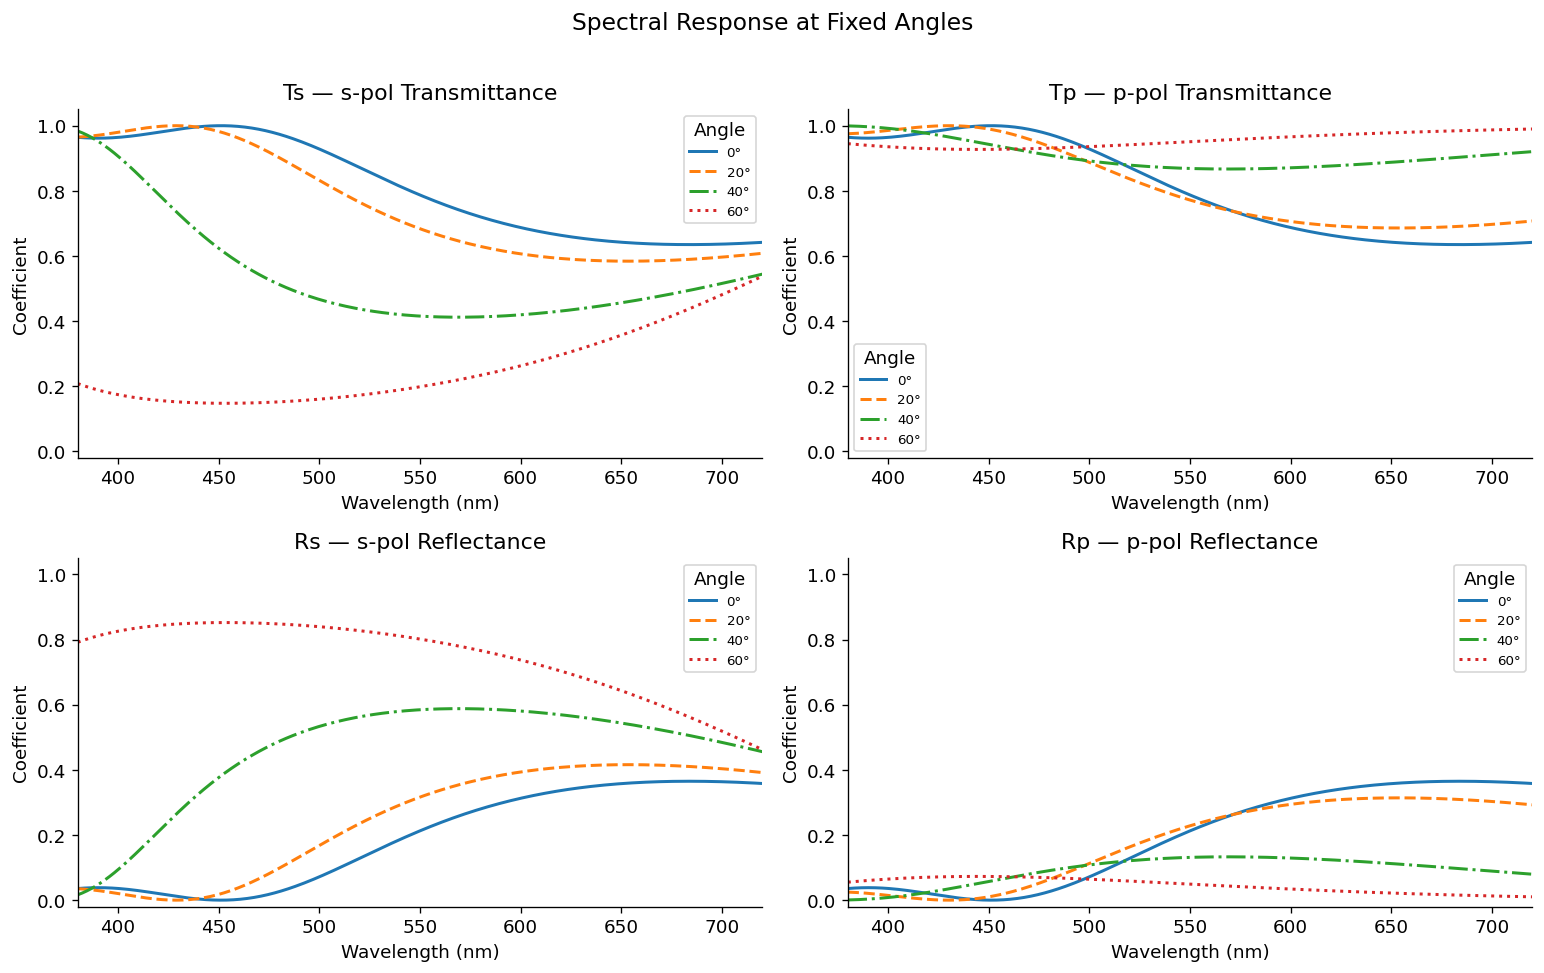

In [9]:
line_styles = ["-", "--", "-.", ":"]
angle_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
titles = [("Ts — s-pol Transmittance", Ts_w),
          ("Tp — p-pol Transmittance", Tp_w),
          ("Rs — s-pol Reflectance",   Rs_w),
          ("Rp — p-pol Reflectance",   Rp_w)]

for ax, (title, data) in zip(axes.flat, titles):
    for ai, (ang, ls, c) in enumerate(zip(fixed_angles_deg, line_styles, angle_colors)):
        ax.plot(wvlns_sweep_nm, data[:, ai], ls=ls, color=c, lw=1.8, label=f"{ang}°")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Coefficient")
    ax.set_title(title)
    ax.set_xlim(380, 720)
    ax.set_ylim(-0.02, 1.05)
    ax.legend(title="Angle", fontsize=8)

fig.suptitle("Spectral Response at Fixed Angles", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 · 2-D heatmap: angle × wavelength

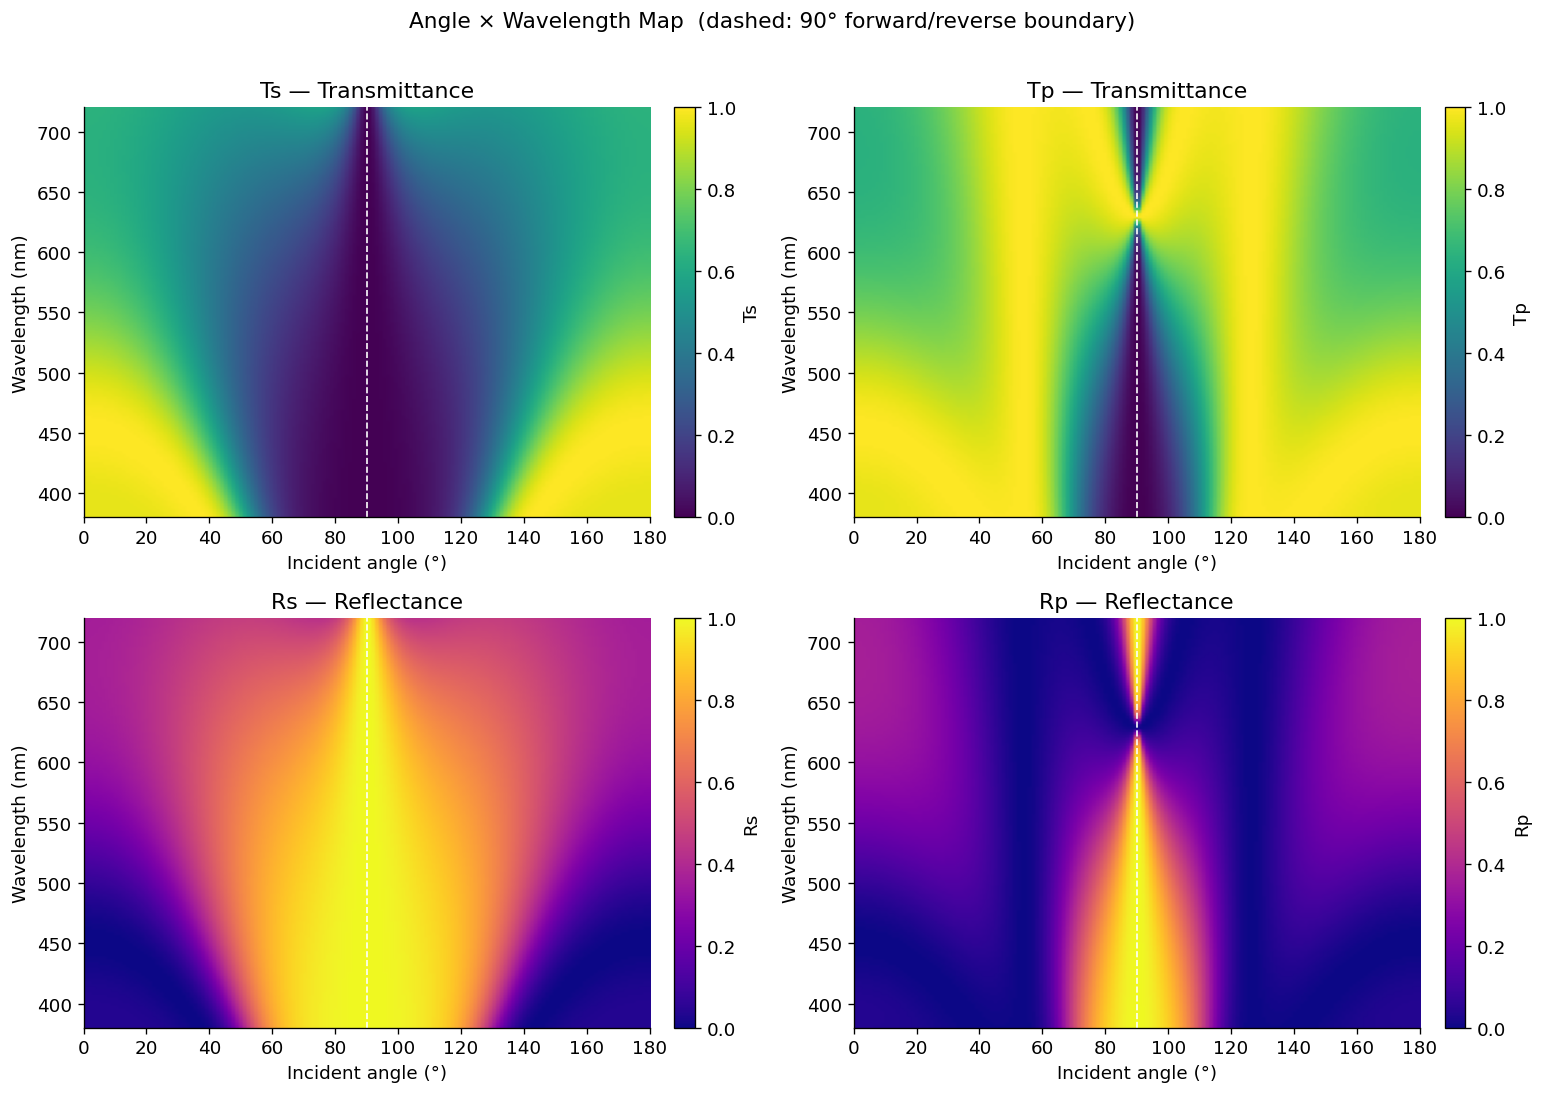

In [10]:
N_a, N_w = 150, 150
# Full 0–180° range covers both forward and reverse propagation
angles_2d = torch.linspace(0.0, torch.pi, N_a, device=device)
wvlns_2d  = torch.linspace(0.38, 0.72, N_w).tolist()

ts_2d, tp_2d, rs_2d, rp_2d = solver.simulate(theta=angles_2d, wvln=wvlns_2d)
# Shape: (1, N_w, N_a)

Ts_2d = (ts_2d[0].abs() ** 2).cpu().numpy()  # (N_w, N_a)
Tp_2d = (tp_2d[0].abs() ** 2).cpu().numpy()
Rs_2d = (rs_2d[0].abs() ** 2).cpu().numpy()
Rp_2d = (rp_2d[0].abs() ** 2).cpu().numpy()

angles_2d_deg = angles_2d.cpu().numpy() * 180 / np.pi
wvlns_2d_nm   = np.array(wvlns_2d) * 1000
extent = [angles_2d_deg[0], angles_2d_deg[-1], wvlns_2d_nm[0], wvlns_2d_nm[-1]]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
maps    = [Ts_2d, Tp_2d, Rs_2d, Rp_2d]
clabels = ["Ts", "Tp", "Rs", "Rp"]
cmaps   = ["viridis", "viridis", "plasma", "plasma"]

for ax, data, label, cmap in zip(axes.flat, maps, clabels, cmaps):
    im = ax.imshow(data, origin="lower", aspect="auto",
                   extent=extent, cmap=cmap, vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)
    ax.axvline(90, color="w", lw=1, ls="--")   # forward/reverse boundary
    ax.set_xlabel("Incident angle (°)")
    ax.set_ylabel("Wavelength (nm)")
    ax.set_title(f"{label} — {'Transmittance' if label[0]=='T' else 'Reflectance'}")

fig.suptitle("Angle × Wavelength Map  (dashed: 90° forward/reverse boundary)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5 · Phase of Fresnel coefficients

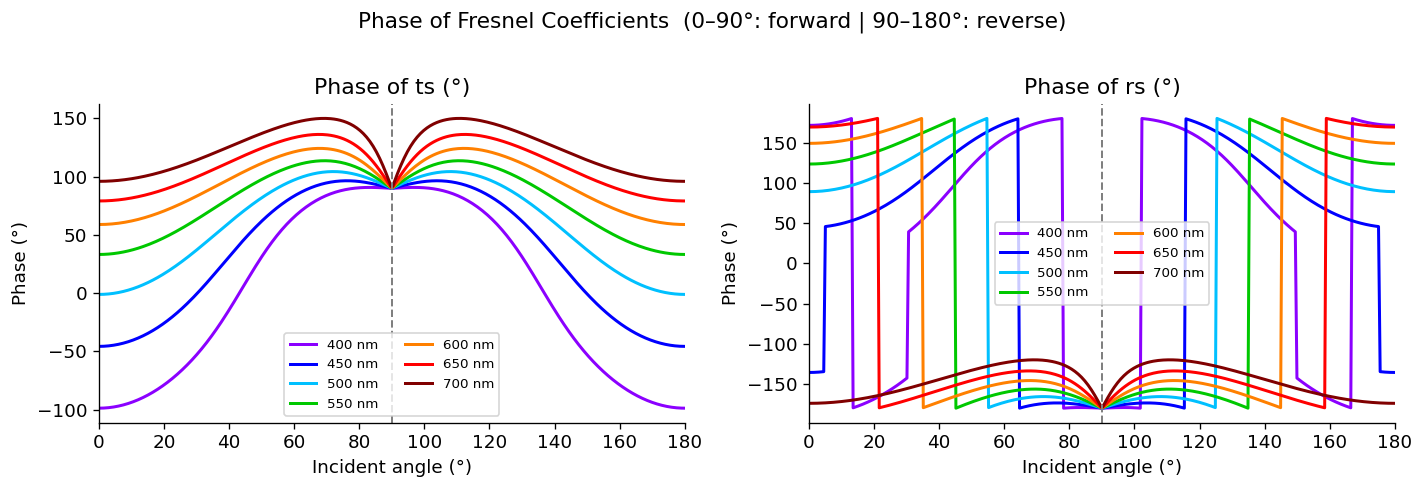

In [11]:
# Re-use angle sweep from Section 2 (0–180°)
phase_ts = torch.angle(ts[0]).cpu().numpy()  # (n_wvlns, n_angles) in radians
phase_rs = torch.angle(rs[0]).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, (wv_nm, c) in enumerate(zip(wvlns_nm, vis_colors)):
    axes[0].plot(angles_deg, np.degrees(phase_ts[i]), color=c, label=f"{wv_nm} nm", lw=1.8)
    axes[1].plot(angles_deg, np.degrees(phase_rs[i]), color=c, label=f"{wv_nm} nm", lw=1.8)

for ax, label in zip(axes, ["Phase of ts (°)", "Phase of rs (°)"]):
    ax.axvline(90, color="gray", lw=1.2, ls="--")
    ax.set_xlabel("Incident angle (°)")
    ax.set_ylabel("Phase (°)")
    ax.set_title(label)
    ax.set_xlim(0, 180)
    ax.legend(fontsize=8, ncol=2)

fig.suptitle("Phase of Fresnel Coefficients  (0–90°: forward | 90–180°: reverse)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6 · Effect of layer thickness on spectral response

Sweep the middle SiO₂ layer thickness while keeping the other layers fixed.

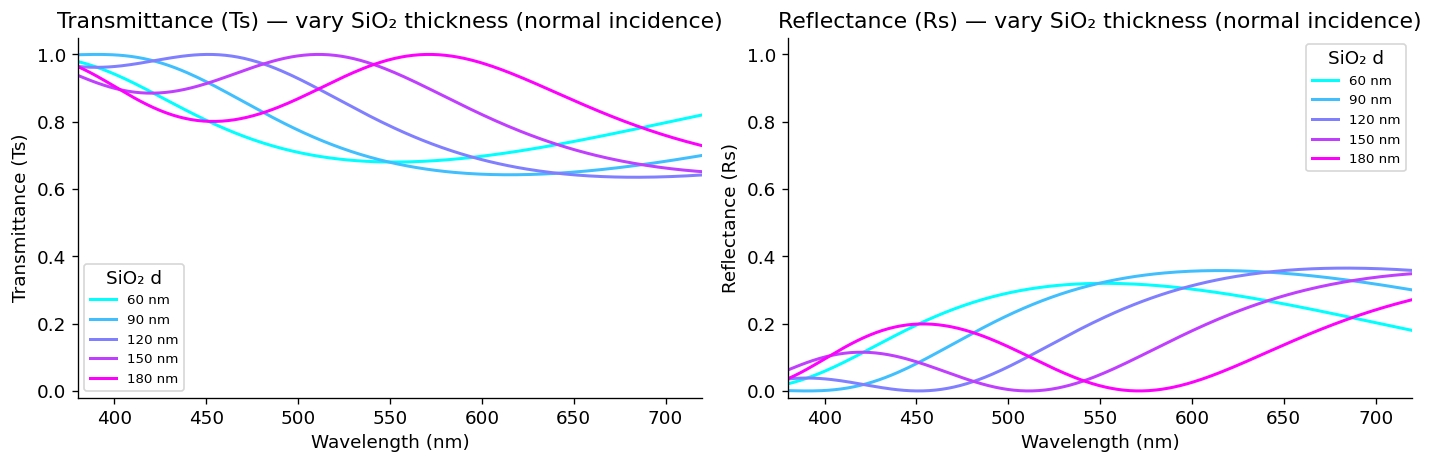

In [12]:
thicknesses = [0.06, 0.09, 0.12, 0.15, 0.18]  # SiO2 thickness in µm
wv_sweep_nm = np.linspace(380, 720, 200)
wv_sweep    = (wv_sweep_nm / 1000).tolist()
angle_fixed = torch.tensor([0.0], device=device)  # normal incidence

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cmap_th = plt.cm.cool
colors_th = [cmap_th(v) for v in np.linspace(0, 1, len(thicknesses))]

for d_sio2, c in zip(thicknesses, colors_th):
    s = IsotropicFilmSolver(
        n_in=n_in, n_out=n_out,
        n_layers_list=n_layers_list,
        d_layers=[0.080, d_sio2, 0.080],
        n_mirrors=1,
        device=device,
    )
    ts_t, _, rs_t, _ = s.simulate(theta=angle_fixed, wvln=wv_sweep)
    Ts_t = (ts_t[0, :, 0].abs() ** 2).cpu().numpy()
    Rs_t = (rs_t[0, :, 0].abs() ** 2).cpu().numpy()
    axes[0].plot(wv_sweep_nm, Ts_t, color=c, lw=1.8, label=f"{d_sio2*1e3:.0f} nm")
    axes[1].plot(wv_sweep_nm, Rs_t, color=c, lw=1.8, label=f"{d_sio2*1e3:.0f} nm")

for ax, ylabel in zip(axes, ["Transmittance (Ts)", "Reflectance (Rs)"]):
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} — vary SiO₂ thickness (normal incidence)")
    ax.legend(title="SiO₂ d", fontsize=8)
    ax.set_xlim(380, 720)
    ax.set_ylim(-0.02, 1.05)

plt.tight_layout()
plt.show()

## 7 · Summary table

Print the same tabular output as `1_forward_simu.py`.

In [13]:
B = 8
angles_tab = torch.linspace(0.0, 1.2, B, device=device)
ts_tab, tp_tab, rs_tab, rp_tab = solver.simulate(theta=angles_tab, wvln=wvlns)

for wi, wv in enumerate(wvlns):
    print(f"\n--- Wavelength = {wv*1000:.0f} nm ---")
    print(f"{'angle (deg)':>12} {'|ts|²':>8} {'|tp|²':>8} {'|rs|²':>8} {'|rp|²':>8} {'T+R (s)':>8}")
    print("-" * 62)
    for ai in range(B):
        Ts_ = (ts_tab[0, wi, ai].abs() ** 2).item()
        Tp_ = (tp_tab[0, wi, ai].abs() ** 2).item()
        Rs_ = (rs_tab[0, wi, ai].abs() ** 2).item()
        Rp_ = (rp_tab[0, wi, ai].abs() ** 2).item()
        ang = angles_tab[ai].item() * 180 / torch.pi
        print(f"{ang:12.2f} {Ts_:8.4f} {Tp_:8.4f} {Rs_:8.4f} {Rp_:8.4f} {Rs_+Ts_:8.4f}")


--- Wavelength = 400 nm ---
 angle (deg)    |ts|²    |tp|²    |rs|²    |rp|²  T+R (s)
--------------------------------------------------------------
        0.00   0.9641   0.9641   0.0359   0.0359   1.0000
        9.82   0.9668   0.9693   0.0332   0.0307   1.0000
       19.64   0.9790   0.9847   0.0210   0.0153   1.0000
       29.47   0.9995   0.9993   0.0005   0.0007   1.0000
       39.29   0.9235   0.9929   0.0765   0.0071   1.0000
       49.11   0.5429   0.9933   0.4571   0.0067   1.0000
       58.93   0.1970   0.9584   0.8030   0.0416   1.0000
       68.75   0.0621   0.5485   0.9379   0.4515   1.0000

--- Wavelength = 450 nm ---
 angle (deg)    |ts|²    |tp|²    |rs|²    |rp|²  T+R (s)
--------------------------------------------------------------
        0.00   1.0000   1.0000   0.0000   0.0000   1.0000
        9.82   0.9994   0.9996   0.0006   0.0004   1.0000
       19.64   0.9838   0.9904   0.0162   0.0096   1.0000
       29.47   0.8922   0.9622   0.1078   0.0378   1.0000
    